# 9. Inflation: breakevens, real curves, linkers and ZC swaps

## Objective

Notebooks 01-08 stayed in the nominal world: one curve of interest rates, and
instruments whose cashflows are fixed in currency. Inflation-linked markets
add a second curve. A **linker** (inflation-linked bond) pays coupons and
principal that are *real* — fixed in purchasing power — scaled into currency by
the ratio of a price index, `I(T)/I(base)`. A **zero-coupon inflation swap**
exchanges a fixed return for realised inflation over one period. Both are
priced off a **breakeven** curve: the spread between nominal and real yields.

This notebook builds a zero-coupon real curve from the packaged synthetic
breakevens, prices a linker with a documented indexation lag, and states the
par breakeven of a zero-coupon inflation swap. Every projected index level is
a *relative* price implied by the breakeven curve — never a CPI forecast.

## Data

The breakeven curve is the packaged dataset
`illustrative_inflation_breakevens`: constructed, not observed (see
`DATA_SOURCES.md`). It carries a zero-coupon breakeven rate per tenor from the
deterministic closed form

$$ b(T) = 0.0230 + 0.0120\,(T/3.0)\,\exp(1 - T/3.0) $$

— a near-term hump that decays to a 2.3% long-run anchor. The breakevens are
continuously compounded zero-coupon rates stored as decimals, matching the
repository's continuous-compounding convention. The nominal curve is the
packaged USD OIS curve already built in notebook 04.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.curves.build import usd_ois_curve
from yieldcurve.inflation import (
    BreakevenCurve,
    InflationLinkedBond,
    RealRateCurve,
    ZeroCouponInflationSwap,
    price_linker,
    zc_swap_legs,
    zc_swap_par_breakeven,
)
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

frame = snapshot.load("illustrative_inflation_breakevens")
print("breakeven columns:", list(frame.columns))
print(frame.to_string(index=False))

breakeven = BreakevenCurve(
    reference_date=ASOF,
    tenors=tuple(float(t) for t in frame["tenor_years"]),
    breakevens=tuple(float(b) for b in frame["breakeven"]),
)
nominal = usd_ois_curve(snapshot, ASOF)
real = RealRateCurve(nominal=nominal, breakeven=breakeven)

breakeven columns: ['tenor_years', 'breakeven']
 tenor_years  breakeven
         1.0   0.030791
         2.0   0.034165
         3.0   0.035000
         5.0   0.033268
         7.0   0.030381
        10.0   0.026879
        15.0   0.024099
        20.0   0.023277
        30.0   0.023015


In [2]:
# ## Theory: the Fisher relation
#
# A breakeven is the inflation rate that equalises the nominal and real return
# over a horizon. With annual compounding the relation is multiplicative:
#
# $$ (1 + n_\text{ann})^T = (1 + r_\text{ann})^T\,(1 + b_\text{ann})^T $$
#
# and in continuous compounding — the repository's convention, where a zero rate
# `z(T)` discounts `exp(-z(T) T)` — it is additive:
#
# $$ n(T) = r(T) + b(T) \quad\Longrightarrow\quad r(T) = n(T) - b(T). $$
#
# The real discount factor is therefore
# `exp(-r(T) T) = exp(-n(T) T) · exp(b(T) T)`: the nominal discount factor
# scaled up by the accumulated breakeven. The breakeven is a **spread between
# two curves** (a relative price), not a forecast of future CPI — it can move on
# liquidity or supply/demand effects without any change in expected inflation.

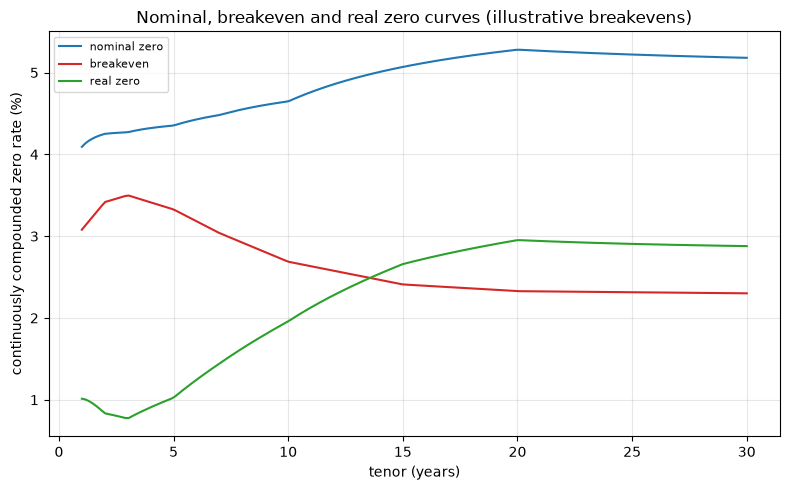

In [3]:
grid = np.linspace(1.0, 30.0, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid, [nominal.zero(float(t)) * 100 for t in grid], label="nominal zero", color="#1f77b4")
ax.plot(
    grid, [breakeven.breakeven(float(t)) * 100 for t in grid], label="breakeven", color="#d62728"
)
ax.plot(grid, [real.zero(float(t)) * 100 for t in grid], label="real zero", color="#2ca02c")
ax.set_xlabel("tenor (years)")
ax.set_ylabel("continuously compounded zero rate (%)")
ax.set_title("Nominal, breakeven and real zero curves (illustrative breakevens)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [4]:
# ## Theory: linker cashflow indexing and the indexation lag
#
# A linker pays real amounts `c_i` at dates `d_i`, converted to currency by the
# indexation ratio:
#
# $$ \text{nominal amount}(d) = \text{real amount} \times \frac{I(d)}{I(\text{base})},
#    \qquad \frac{I(d)}{I(\text{base})} = \exp\bigl(b(t)\,t\bigr). $$
#
# The index used for a payment is observed with a **lag**: the CPI for a month
# is published weeks after the month closes, so a payment dated `d` settles
# against the index published `indexation_lag_months` earlier. Here that lag is
# applied as a *shift of the index observation date* — the projected index is
# evaluated at `d - lag` — a documented simplification (a desk would interpolate
# the fixing inside the lag). With the lag at zero, the real-curve price and the
# nominal-curve price of the indexed cashflows coincide exactly by the Fisher
# identity; the lag is the only thing that separates them.

In [5]:
bond = InflationLinkedBond(
    base_date=ASOF,
    maturity=date(2036, 7, 24),
    face=100.0,
    coupon=0.02,
    frequency=2,
    base_index=100.0,
    indexation_lag_months=3,
)
priced = price_linker(bond, real, ASOF)
print("10y linker, 2% real coupon, semiannual, 3-month indexation lag:")
print(f"  real price    = {priced.real_price:.4f}  (deflated cashflows, real curve)")
print(f"  nominal price = {priced.nominal_price:.4f}  (indexed cashflows, nominal curve)")
print(f"  maturity index ratio = {priced.maturity_index_ratio:.4f}  (I(T - 3M) / I(base))")
print(f"  lag effect (nominal - real) = {priced.nominal_price - priced.real_price:+.4f}")

10y linker, 2% real coupon, semiannual, 3-month indexation lag:
  real price    = 100.7637  (deflated cashflows, real curve)
  nominal price = 100.3169  (indexed cashflows, nominal curve)
  maturity index ratio = 1.3035  (I(T - 3M) / I(base))
  lag effect (nominal - real) = -0.4468


In [6]:
# ## Results: the zero-coupon inflation swap
#
# A zero-coupon inflation swap exchanges, at maturity `T`, the fixed return
# `exp(K T) - 1` for realised inflation `exp(b(T) T) - 1`. At par the two
# terminal amounts coincide, which forces `K = b(T)`: the par breakeven **is**
# the zero-coupon breakeven at `T`. Both legs are discounted on the nominal
# curve, so a par swap has zero net value by construction.

In [7]:
swap = ZeroCouponInflationSwap(
    start_date=ASOF, maturity=date(2036, 7, 24), notional=1.0, fixed_breakeven=0.02
)
par = zc_swap_par_breakeven(breakeven, ASOF, date(2036, 7, 24))
legs = zc_swap_legs(swap, nominal, breakeven)
print("10y zero-coupon inflation swap, notional 1:")
print(f"  par breakeven = {par * 100:.4f}%  (the ZC breakeven at 10y)")
print(f"  fixed leg PV    = {legs.fixed_leg_pv:.6f}  (pays exp(0.02 * T) - 1)")
print(f"  floating leg PV = {legs.floating_leg_pv:.6f}  (pays exp(b(T) T) - 1)")
print(f"  net PV (fixed - floating, at K=2%) = {legs.net_pv:+.6f}")

10y zero-coupon inflation swap, notional 1:
  par breakeven = 2.6874%  (the ZC breakeven at 10y)
  fixed leg PV    = 0.139170  (pays exp(0.02 * T) - 1)
  floating leg PV = 0.193811  (pays exp(b(T) T) - 1)
  net PV (fixed - floating, at K=2%) = -0.054641


In [8]:
# ## Limitations
#
# - **Illustrative data.** The breakevens are constructed, not observed; the
#   prices describe a synthetic curve, not a traded market.
# - **Zero-coupon, spot-starting only.** The swap is a single-period, spot-start
#   contract; forward-starting swaps and a full (seasonally adjusted) inflation
#   surface are out of scope.
# - **Lag as a date shift.** The indexation lag shifts the index observation
#   date; it does not interpolate the CPI fixing inside the lag and ignores
#   seasonality, which a real linker price would include.
# - **No convexity or optionality.** The breakeven is priced as a deterministic
#   spread; there is no inflation-option (cap/floor) modelling.

In [9]:
# ## Regulatory context
#
# Zero-coupon inflation swaps are **OTC derivative contracts**. Under EMIR
# (Regulation (EU) No 648/2012), Article 1(1)-(2), the clearing, bilateral
# risk-management and reporting obligations attach to OTC derivatives. This
# repository uses the inflation-swap convention only as a pricing
# demonstration: it does not originate, hold, clear or report any derivative
# position, so no EMIR obligation attaches to the toolkit itself — the same
# boundary the repository's regulation note already records for its
# interest-rate swaps.
#
# The breakeven is a **spread, not a forecast**: it prices the relative value of
# nominal and inflation-linked cashflows and is not a prediction of future CPI.
# Under IFRS 13, a constructed breakeven is an unobservable (Level 3) input, and
# no automatic fair-value classification follows from using it; this notebook
# performs no entity-level fair-value measurement. The hand-derived references
# in `tests/inflation/test_inflation.py` are software verification — the Fisher
# identity and the ZC-swap par condition re-derived by hand — not empirical or
# regulatory model validation.